In [25]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [26]:
# gpu_info = !nvidia-smi
# gpu_info = '\n'.join(gpu_info)
# if gpu_info.find('failed') >= 0:
#   print('Not connected to a GPU')
# else:
#   print(gpu_info)

In [27]:
dfs = {}

df = pd.read_csv('/content/Station1_Revised_Final_Data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
dfs['Station1'] = df
# for index in range(0, 6):
#   df = pd.read_csv('Station' + str(index + 1) + '_simulated_cleaned_merged_data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
#   dfs['Station' + str(index + 1)] = df
#   df.index = pd.to_datetime(df.index)

print(df.isna().sum())


Ppt              0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
Latitude         0
Longitude        0
dtype: int64


In [28]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,0.068205,8.405104e-01,-1.464373,0.0000,0.0000,0.0000,40.640000
SWC_5,52560.0,0.140254,5.154907e-02,0.004612,0.0950,0.1340,0.1830,0.309000
SWC_10,52560.0,0.157113,4.093361e-02,-0.023168,0.1230,0.1540,0.1920,0.298000
SWC_20,52560.0,0.137294,3.346671e-02,0.049357,0.1050,0.1360,0.1650,0.235000
SWC_50,52560.0,0.137377,3.578278e-02,0.076554,0.1030,0.1290,0.1700,0.249000
T_5,52560.0,22.992845,9.495459e+00,0.760000,15.5500,22.9300,30.0800,49.960000
T_10,52560.0,23.007369,8.874525e+00,2.000000,15.8000,23.1100,30.1700,44.440000
T_20,52560.0,22.948400,8.384273e+00,3.270000,15.9400,23.0800,30.0100,41.200000
T_50,52560.0,22.805075,7.007613e+00,7.880000,16.5200,22.5900,29.2300,35.400000
Tair,52560.0,14.142881,2.328434e+01,-173.200000,11.5775,19.3300,24.4200,172.476413


In [29]:
import numpy as np
import pandas as pd

def engineer_data(dfs, boolean):
    # Constants for day and year calculations
    day = 24 * 60 * 60
    year = 365.2425 * day

    for station, df in dfs.items():
        # Drop rows with NaN values to ensure clean data
        df = df.dropna()

        # Extract windspeed and wind direction
        wv = df['Windspeed']
        wd_rad = np.deg2rad(df['Winddirection'])  # Convert degrees to radians

        # Ensure the index is in datetime format
        df.index = pd.to_datetime(df.index)

        # Convert timestamp index to seconds
        timestamp_s = df.index.map(pd.Timestamp.timestamp)

        # Extract latitude and longitude
        lat = np.deg2rad(df['Latitude'])  # Convert latitude to radians
        lon = np.deg2rad(df['Longitude'])  # Convert longitude to radians

        # Engineer wind components

        # print("HELLO", wv * np.cos(wd_rad))
        # print("AHHHHH",wd_rad)

        if boolean:
          df['Wx'] = wv * np.cos(wd_rad)
          df['Wy'] = wv * np.sin(wd_rad)

        # Engineer time-based cyclic features
        df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
        df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
        df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
        df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

        # Engineer Cartesian coordinates for latitude and longitude
        df['x_cord'] = np.cos(lat) * np.cos(lon)
        df['y_cord'] = np.cos(lat) * np.sin(lon)
        df['z_cord'] = np.sin(lat)

        # Update the DataFrame in the dictionary
        dfs[station] = df

    return dfs





In [30]:
engineer_data(dfs, False)

engineer_data(dfs, True)



{'Station1':                      Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
 2015-01-01 00:00:00  0.0  0.139   0.178   0.148   0.152  2.81  4.40  5.77   
 2015-01-01 01:00:00  0.0  0.139   0.178   0.148   0.152  2.86  4.38  5.71   
 2015-01-01 02:00:00  0.0  0.139   0.178   0.148   0.152  2.89  4.35  5.66   
 2015-01-01 03:00:00  0.0  0.139   0.178   0.148   0.152  2.90  4.33  5.62   
 2015-01-01 04:00:00  0.0  0.139   0.178   0.148   0.152  2.96  4.32  5.59   
 ...                  ...    ...     ...     ...     ...   ...   ...   ...   
 2020-12-31 19:00:00  0.0  0.242   0.193   0.182   0.099  5.46  6.95  8.62   
 2020-12-31 20:00:00  0.0  0.236   0.191   0.182   0.099  5.43  6.80  8.40   
 2020-12-31 21:00:00  0.0  0.232   0.190   0.181   0.099  5.30  6.68  8.24   
 2020-12-31 22:00:00  0.0  0.229   0.189   0.181   0.099  5.29  6.55  8.09   
 2020-12-31 23:00:00  0.0  0.227   0.188   0.181   0.099  5.28  6.50  7.96   
 
                       T_50   Tair  ...  Longitude

In [31]:
dfs['Station1'].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,6.820478e-02,8.405104e-01,-1.464373,0.000000,0.000000e+00,0.000000,40.640000
SWC_5,52560.0,1.402540e-01,5.154907e-02,0.004612,0.095000,1.340000e-01,0.183000,0.309000
SWC_10,52560.0,1.571126e-01,4.093361e-02,-0.023168,0.123000,1.540000e-01,0.192000,0.298000
SWC_20,52560.0,1.372937e-01,3.346671e-02,0.049357,0.105000,1.360000e-01,0.165000,0.235000
SWC_50,52560.0,1.373766e-01,3.578278e-02,0.076554,0.103000,1.290000e-01,0.170000,0.249000
T_5,52560.0,2.299284e+01,9.495459e+00,0.760000,15.550000,2.293000e+01,30.080000,49.960000
T_10,52560.0,2.300737e+01,8.874525e+00,2.000000,15.800000,2.311000e+01,30.170000,44.440000
T_20,52560.0,2.294840e+01,8.384273e+00,3.270000,15.940000,2.308000e+01,30.010000,41.200000
T_50,52560.0,2.280507e+01,7.007613e+00,7.880000,16.520000,2.259000e+01,29.230000,35.400000
Tair,52560.0,1.414288e+01,2.328434e+01,-173.200000,11.577500,1.933000e+01,24.420000,172.476413


In [32]:
def scale_data(dfs):
    for station, df in dfs.items():
        cur_df = df.copy()
        d_sin = cur_df.pop("Day sin")
        d_cos = cur_df.pop("Day cos")
        y_sin = cur_df.pop("Year sin")
        y_cos = cur_df.pop("Year cos")
        x = cur_df.pop("x_cord")
        y = cur_df.pop("y_cord")
        z = cur_df.pop("z_cord")
        scaler = MinMaxScaler()
        scaled_df = pd.DataFrame(data=scaler.fit_transform(cur_df), columns=cur_df.columns, index=cur_df.index)
        scaled_df["Day sin"] = d_sin.values
        scaled_df["Day cos"] = d_cos.values
        scaled_df["Year sin"] = y_sin.values
        scaled_df["Year cos"] = y_cos.values
        scaled_df["x_cord"] = x.values
        scaled_df["y_cord"] = y.values
        scaled_df["z_cord"] = z.values
        dfs[station] = scaled_df

In [33]:
scale_data(dfs)

In [34]:
#Definitions
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24 * 7
SHIFT_AMT = 10
PAT = 3
MAX_EPOCHS = 25

In [35]:
def split(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values
  return (train_set, val_set, test_set, target_idx)

In [36]:
def generate_windows(data, window_size=24, shift=24, target_idx=0):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift):
        # get window based on input width
        window = data[i : i + window_size]
        window_label = labels[i + window_size + shift]

        X.append(window)
        y.append(window_label)

    # in new dataset, each element is a data window, and window label is single value
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=32):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)


In [37]:
def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [38]:
cur_df = dfs["Station1"]

BATCH_SIZE = 128
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(cur_df)

# divide each dataset into batched version to feed to models
train_dataset, train_steps = generate_batches(X_train, y_train, batch_size=BATCH_SIZE)
val_dataset, val_steps = generate_batches(X_val, y_val, batch_size=BATCH_SIZE)
test_dataset, test_steps = generate_batches(X_test, y_test, batch_size=BATCH_SIZE)

Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude',
       'Longitude', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
       'x_cord', 'y_cord', 'z_cord'],
      dtype='object')


In [39]:
def compile_and_fit(model, data, steps_per_epoch, val_data, val_steps, model_name='model/', patience=3, max_epochs=MAX_EPOCHS, batch_size=32):
    # stop running epochs if the loss stops improving for patience number of epochs
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, mode='min')

    # store the best model on disk to be loaded later without having to re-fit
    # allows you to load models from disc
    ckpt = tf.keras.callbacks.ModelCheckpoint(model_name + ".keras", save_best_only=True)

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.MeanAbsolutePercentageError()])

    history = model.fit(data,
                        epochs=max_epochs,
                        callbacks=[ckpt, early_stopping],
                        validation_data=val_data,
                        validation_steps=val_steps,
                        shuffle=False,
                        batch_size=batch_size,
                        steps_per_epoch = steps_per_epoch)

    return history

In [86]:
preds = {}

def plot_single_pred(model, name, dataset, data_steps, y, batch_size=32, shift=24):
    forecast = model.predict(dataset, batch_size=batch_size, steps=data_steps)
    preds[name] = forecast
    if len(forecast.shape) == 3:
        print("asd")
        forecast = forecast[:, 0, 0]
    elif len(forecast.shape) == 2:
        forecast = forecast[:, 0]

  #delete later
    time_indices = np.arange(0, len(forecast) * shift, shift)

    plt.figure(figsize=(10, 6))
    plot_data = {"Predictions": forecast, "Actual": y}

    plt.plot(plot_data["Actual"])
    plt.plot(plot_data["Predictions"])

    plt.legend(("Actual", "Predictions"))

    return plot_data

    # plt.figure(figsize=(10, 6))

    # # Plot actual values on a continuous hourly scale
    # plt.plot(np.arange(len(y)), y, label="Actual")

    # # Plot predictions at 24-hour intervals using time_indices
    # plt.plot(time_indices, forecast, label="Predictions")

    # plt.xlabel("Time (in hours)")
    # plt.ylabel("Value")
    # plt.legend()
    # plt.title(f"Actual vs Predicted ({name}) with 24-Hour Shift")

    # plt.show()

In [94]:
lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=False),
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [42]:
bi_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=False)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh'),
])

In [43]:
!pip install keras-self-attention

In [44]:
#LSTM with an attention layer -
# https://stackoverflow.com/questions/58966874/adding-attention-on-top-of-simple-lstm-layer-in-tensorflow-2-0
# https://pypi.org/project/keras-self-attention/

from keras_self_attention import SeqSelfAttention


lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='softmax'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [47]:
#biLSTM with an attention layer

bi_lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='softmax'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

In [48]:
loss_by_epoch = {}
val_performance = {}
performance = {}

In [ ]:
#uncessary models

# # https://www.tensorflow.org/tutorials/structured_data/time_series#baseline

# linear_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1)
# ])


# dense_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=64, activation='relu'),
#     tf.keras.layers.Dense(units=32, activation='relu'),
#     tf.keras.layers.Dense(units=1)
# ])


# cnn_model = tf.keras.Sequential([
#     tf.keras.layers.Conv1D(filters=32, kernel_size=5,
#                       activation='relu', input_shape=X_train.shape[-2:]),
#     tf.keras.layers.MaxPooling1D(pool_size=4),
#     tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu'),
#     tf.keras.layers.MaxPooling1D(pool_size=4),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(units=1)
# ])


# rnn_model = tf.keras.Sequential([
#     tf.keras.layers.SimpleRNN(128, return_sequences=True),
#     tf.keras.layers.SimpleRNN(64, return_sequences=True),
#     tf.keras.layers.SimpleRNN(32, return_sequences=False),
#     tf.keras.layers.Dense(units=1)
# ])


# autoregressive_model = tf.keras.Sequential([
#     tf.keras.layers.Dense(units=1, input_shape=X_train.shape[-2:])
# ])


In [49]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTM" + ".keras", save_best_only=True) # add the .keras extension to the filepath


bi_LSTM_history = compile_and_fit(bi_lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTM", patience=PAT)
loss_by_epoch["biLSTM"] = bi_LSTM_history.history
val_performance["biLSTM"] = bi_lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTM"] = bi_lstm_model.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)

Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - loss: 0.0534 - mean_absolute_error: 0.1714 - mean_absolute_percentage_error: 1851.6998 - mean_squared_error: 0.0534 - val_loss: 0.0233 - val_mean_absolute_error: 0.1316 - val_mean_absolute_percentage_error: 35.9247 - val_mean_squared_error: 0.0233
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0111 - mean_absolute_error: 0.0810 - mean_absolute_percentage_error: 1899.7754 - mean_squared_error: 0.0111 - val_loss: 0.0579 - val_mean_absolute_error: 0.1938 - val_mean_absolute_percentage_error: 47.5441 - val_mean_squared_error: 0.0579
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0113 - mean_absolute_error: 0.0781 - mean_absolute_percentage_error: 1879.9468 - mean_squared_error: 0.0113 - val_loss: 0.0559 - val_mean_absolute_error: 0.1961 - val_mean_absolute_percentage_error: 46.4175 - val_mean_squared_error: 0.0559
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - loss: 0.0102 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


{'Predictions': array([0.23089075, 0.23063579, 0.230341  , ..., 0.5257164 , 0.5286206 ,
        0.53082967], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

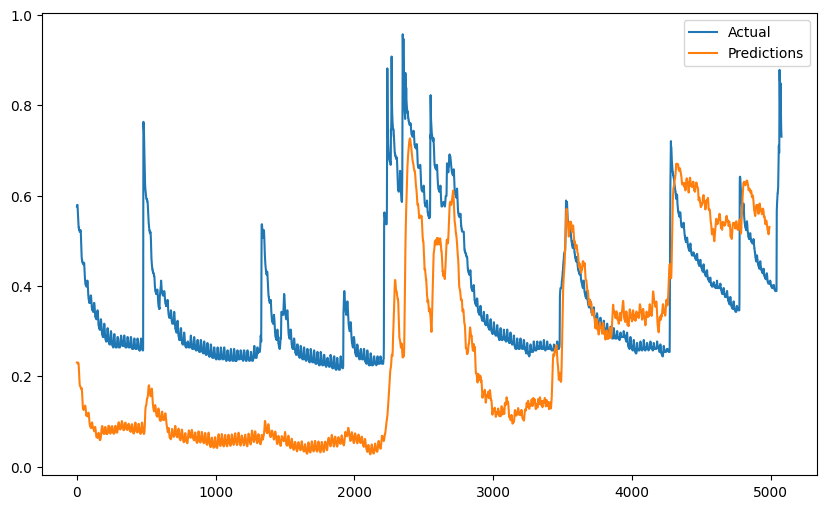

In [90]:
plot_single_pred(bi_lstm_model,'BiLSTM', test_dataset, test_steps, y_test, batch_size=1)

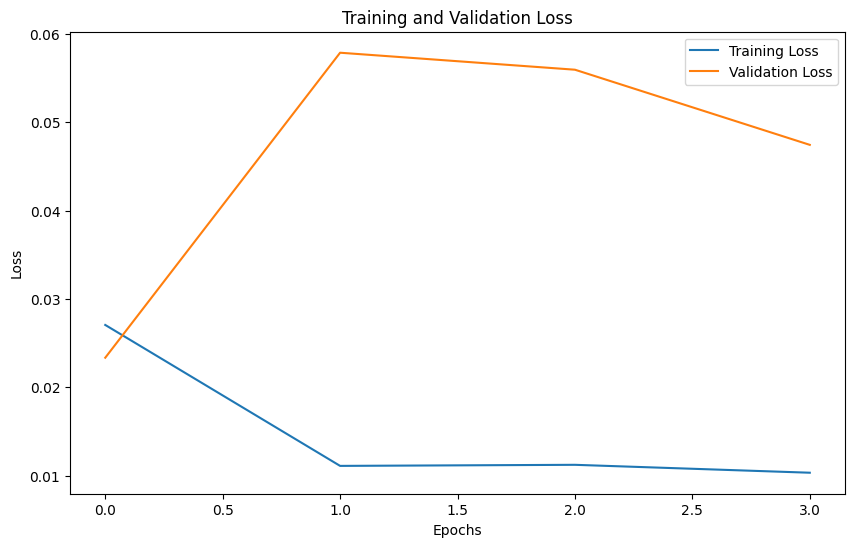

In [53]:
import matplotlib.pyplot as plt

# plotting training vs validation loss
history = bi_LSTM_history.history

plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [95]:
ckpt = tf.keras.callbacks.ModelCheckpoint("LSTM" + ".keras", save_best_only=True) # add the .keras extension to the filepath


LSTM_history = compile_and_fit(lstm_model, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="LSTM", patience=PAT)
loss_by_epoch["LSTM"] = LSTM_history.history
val_performance["LSTM"] = lstm_model.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["LSTM"] = lstm_model.evaluate


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - loss: 0.0561 - mean_absolute_error: 0.1743 - mean_absolute_percentage_error: 2979.9426 - mean_squared_error: 0.0561 - val_loss: 0.0300 - val_mean_absolute_error: 0.1471 - val_mean_absolute_percentage_error: 41.5770 - val_mean_squared_error: 0.0300
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - loss: 0.0133 - mean_absolute_error: 0.0911 - mean_absolute_percentage_error: 2037.4998 - mean_squared_error: 0.0133 - val_loss: 0.0407 - val_mean_absolute_error: 0.1692 - val_mean_absolute_percentage_error: 46.4177 - val_mean_squared_error: 0.0407
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 0.0148 - mean_absolute_error: 0.0941 - mean_absolute_percentage_error: 1714.4224 - mean_squared_error: 0.0148 - val_loss: 0.0257 - val_mean_absolute_error: 0.1280 - val_mean_absolute_percentage_error: 29.0685 - val_mean_squared_error: 0.0257
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - loss: 0.0125 - mean_absolute_error

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


{'Predictions': array([0.5626633 , 0.56386954, 0.564028  , ..., 0.37491968, 0.37924615,
        0.38362706], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

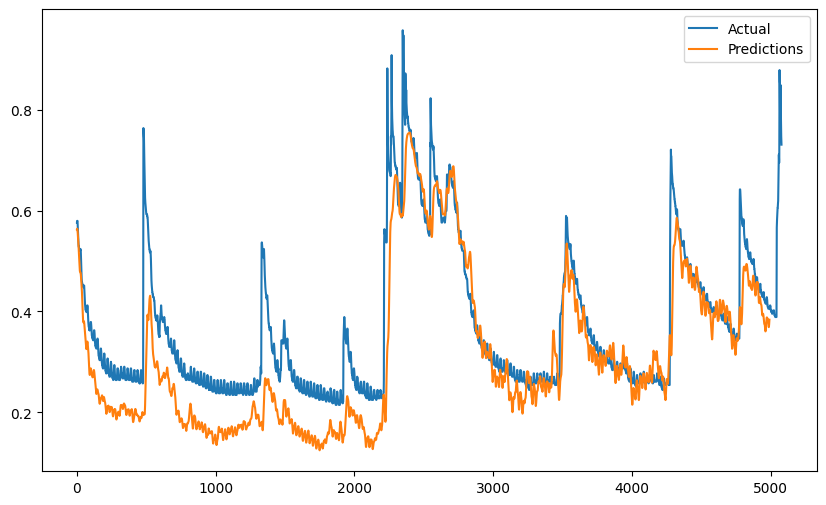

In [96]:
plot_single_pred(lstm_model,'LSTM', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

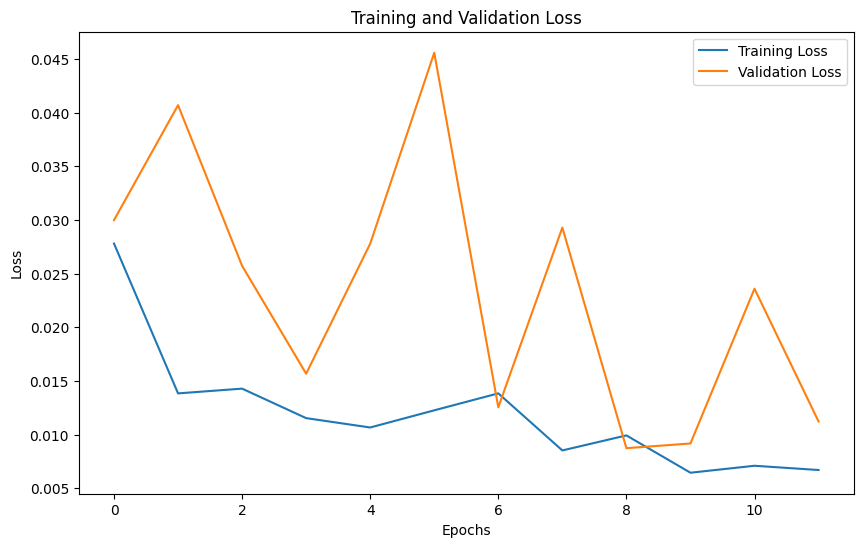

In [97]:
import matplotlib.pyplot as plt

# plotting training vs validation loss
history = LSTM_history.history

plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
!pip install keras-self-attention


In [61]:
# Compile the model
lstm_model_with_attention.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                                  loss='mse',
                                  metrics=['mae', 'mse'])

ckpt = tf.keras.callbacks.ModelCheckpoint("lstmWithSelfAttention" + ".keras", save_best_only=True)

# Train the model using the compile_and_fit function
lstm_with_attention_history = compile_and_fit(lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps,
                                              batch_size=BATCH_SIZE, model_name="lstmWithSelfAttention", patience=PAT)
loss_by_epoch["lstmWithSelfAttention"] = lstm_with_attention_history.history

val_performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 28s 82ms/step - loss: 0.0109 - mean_absolute_error: 0.0772 - mean_absolute_percentage_error: 2909.7163 - mean_squared_error: 0.0109 - val_loss: 0.0152 - val_mean_absolute_error: 0.1050 - val_mean_absolute_percentage_error: 26.9842 - val_mean_squared_error: 0.0152
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - loss: 0.0110 - mean_absolute_error: 0.0785 - mean_absolute_percentage_error: 2798.0159 - mean_squared_error: 0.0110 - val_loss: 0.0132 - val_mean_absolute_error: 0.0961 - val_mean_absolute_percentage_error: 23.1321 - val_mean_squared_error: 0.0132
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0107 - mean_absolute_error: 0.0774 - mean_absolute_percentage_error: 2924.6304 - mean_squared_error: 0.0107 - val_loss: 0.0149 - val_mean_absolute_error: 0.1019 - val_mean_absolute_percentage_error: 25.6779 - val_mean_squared_error: 0.0149
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0103 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
asd


{'Predictions': array([0.55973315, 0.5595458 , 0.55952156, ..., 0.40337077, 0.40365237,
        0.40370965], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

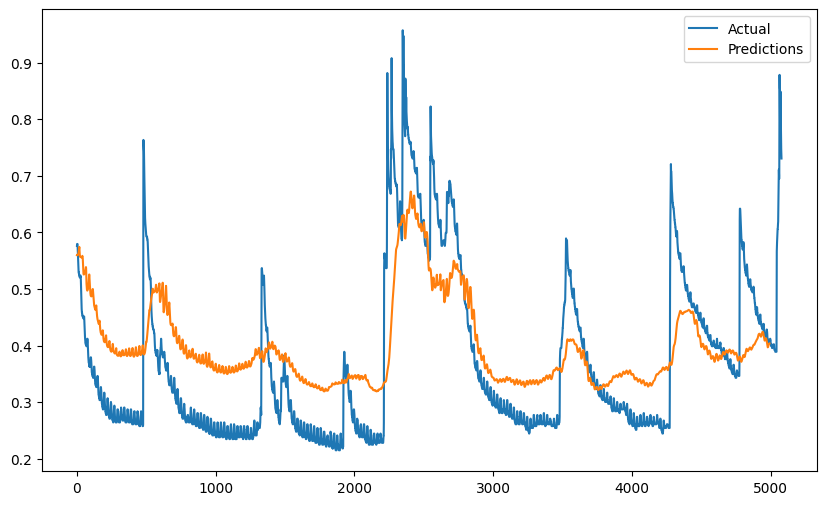

In [88]:
plot_single_pred(lstm_model_with_attention,'LSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

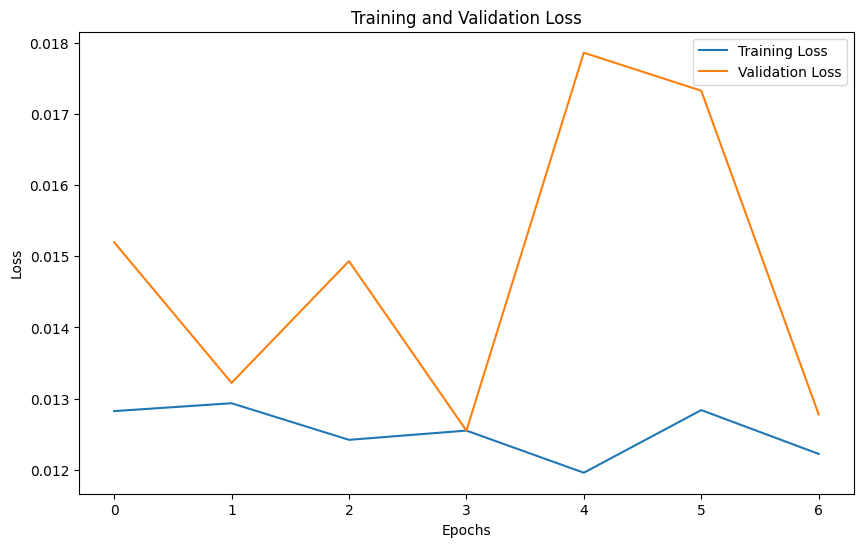

In [63]:
import matplotlib.pyplot as plt

# plotting training vs validation loss
history = lstm_with_attention_history.history

plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [64]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTMWithSelfAttention" + ".keras", save_best_only=True) # add the .keras extension to the filepath

bi_lstm_model_with_attention_history = compile_and_fit(bi_lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTMWithSelfAttention", patience=PAT)
loss_by_epoch["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention_history.history
val_performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - loss: 0.0445 - mean_absolute_error: 0.1551 - mean_absolute_percentage_error: 2128.0098 - mean_squared_error: 0.0445 - val_loss: 0.0167 - val_mean_absolute_error: 0.1120 - val_mean_absolute_percentage_error: 27.8698 - val_mean_squared_error: 0.0167
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - loss: 0.0154 - mean_absolute_error: 0.0958 - mean_absolute_percentage_error: 2317.3408 - mean_squared_error: 0.0154 - val_loss: 0.0153 - val_mean_absolute_error: 0.1050 - val_mean_absolute_percentage_error: 25.3774 - val_mean_squared_error: 0.0153
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - loss: 0.0135 - mean_absolute_error: 0.0882 - mean_absolute_percentage_error: 2643.6411 - mean_squared_error: 0.0135 - val_loss: 0.0139 - val_mean_absolute_error: 0.0964 - val_mean_absolute_percentage_error: 22.0718 - val_mean_squared_error: 0.0139
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - loss: 0.0121 - mean_absolute

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
asd


{'Predictions': array([0.6674216 , 0.66719955, 0.6670414 , ..., 0.4116491 , 0.41113788,
        0.41074306], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

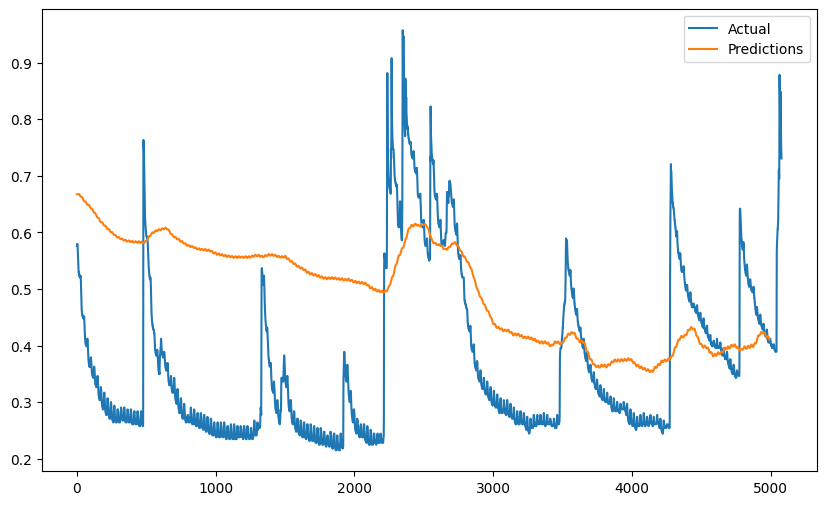

In [98]:
plot_single_pred(bi_lstm_model_with_attention,'BiLSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)

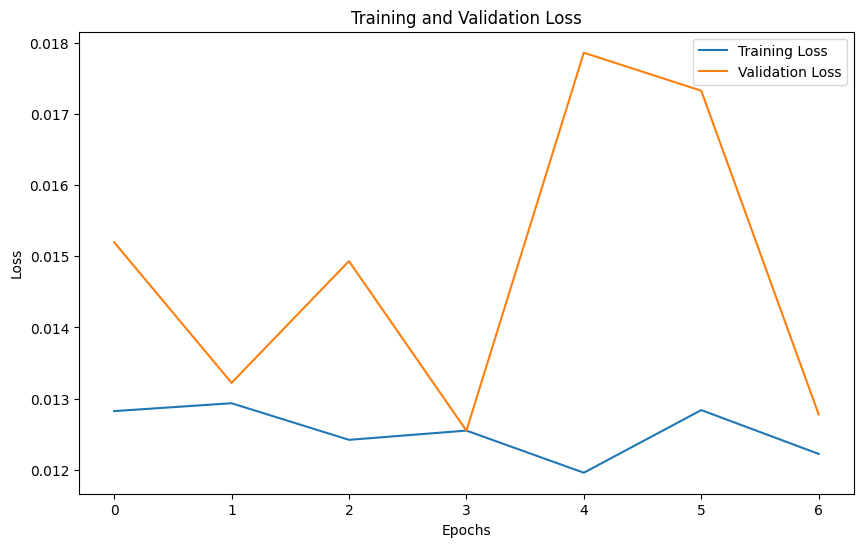

In [66]:
import matplotlib.pyplot as plt

# plotting training vs validation loss
history = lstm_with_attention_history

plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [67]:
# trying again with differenet activation functions for the attention layer (sigmoid now)
from keras_self_attention import SeqSelfAttention


lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(128, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(32, return_sequences=True),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='sigmoid'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])

#biLSTM with an attention layer

bi_lstm_model_with_attention = tf.keras.models.Sequential([
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True)),  # Set return_sequences=True for attention
    SeqSelfAttention(attention_activation='sigmoid'),  # Add attention layer
    tf.keras.layers.Dense(units=32, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='tanh')
])




In [69]:
# Define the inputs explicitly for more control
#https://www.tensorflow.org/api_docs/python/tf/keras/layers/Attention


inputs = tf.keras.layers.Input(shape=(None, X_train.shape[-1]))

# BiLSTM layers
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True))(inputs)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True))(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32, return_sequences=True))(x)

# Attention layer
attention = tf.keras.layers.Attention()([x, x])

# Flatten or use additional layers as needed
x = tf.keras.layers.Dense(32, activation='relu')(attention)
outputs = tf.keras.layers.Dense(1, activation='tanh')(x)

# Final model
bi_lstm_model_with_attention = tf.keras.Model(inputs=inputs, outputs=outputs)

In [71]:
ckpt = tf.keras.callbacks.ModelCheckpoint("biLSTMWithSelfAttention" + ".keras", save_best_only=True) # add the .keras extension to the filepath

bi_lstm_model_with_attention_history = compile_and_fit(bi_lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps, batch_size=BATCH_SIZE, model_name="biLSTMWithSelfAttention", patience=PAT)
loss_by_epoch["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention_history.history
val_performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["biLSTMWithSelfAttention"] = bi_lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - loss: 0.0519 - mean_absolute_error: 0.1586 - mean_absolute_percentage_error: 2535.7412 - mean_squared_error: 0.0519 - val_loss: 0.0272 - val_mean_absolute_error: 0.1316 - val_mean_absolute_percentage_error: 30.7055 - val_mean_squared_error: 0.0272
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - loss: 0.0179 - mean_absolute_error: 0.1043 - mean_absolute_percentage_error: 2806.5178 - mean_squared_error: 0.0179 - val_loss: 0.0611 - val_mean_absolute_error: 0.2075 - val_mean_absolute_percentage_error: 60.1794 - val_mean_squared_error: 0.0611
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - loss: 0.0198 - mean_absolute_error: 0.1111 - mean_absolute_percentage_error: 2170.6272 - mean_squared_error: 0.0198 - val_loss: 0.0477 - val_mean_absolute_error: 0.1821 - val_mean_absolute_percentage_error: 52.7015 - val_mean_squared_error: 0.0477
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - loss: 0.0180 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
asd


{'Predictions': array([0.6674216 , 0.66719955, 0.6670414 , ..., 0.4116491 , 0.41113788,
        0.41074306], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

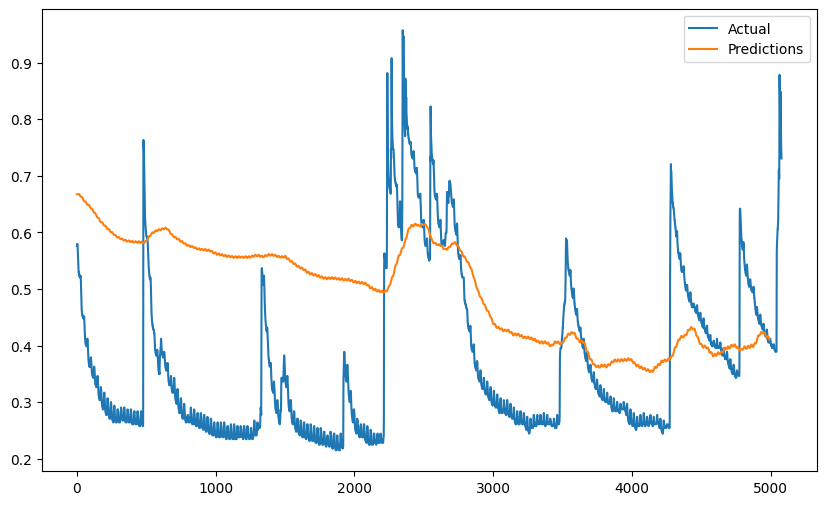

In [82]:
plot_single_pred(bi_lstm_model_with_attention,'BiLSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)


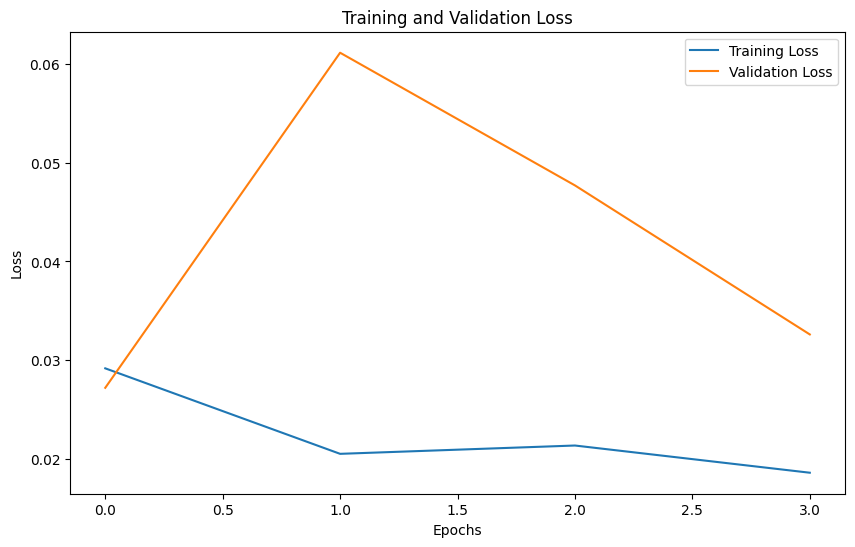

In [73]:
import matplotlib.pyplot as plt

# plotting training vs validation loss
history = bi_lstm_model_with_attention_history.history

plt.figure(figsize=(10, 6))
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [74]:
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Dropout, AdditiveAttention, Permute, Reshape, Multiply, Input, Flatten

# Define the input layer
# https://drlee.io/advanced-stock-pattern-prediction-using-lstm-with-the-attention-mechanism-in-tensorflow-a-step-by-143a2e8b0e95

input_layer = Input(shape=(X_train.shape[1], 1))

# Adding LSTM layers with return_sequences=True
lstm_layer_1 = LSTM(units=50, return_sequences=True)(input_layer)
lstm_layer_2 = LSTM(units=50, return_sequences=True)(lstm_layer_1)

# Self-Attention mechanism
attention_layer = AdditiveAttention(name='attention_weight')([lstm_layer_2, lstm_layer_2])

# Element-wise multiplication to apply attention weights
attention_result = Multiply()([lstm_layer_2, attention_layer])

# Flatten the output to feed into Dense layers
flatten_layer = Flatten()(attention_result)

# Output layer
output_layer = Dense(1)(flatten_layer)

# Final model
lstm_model = Model(inputs=input_layer, outputs=output_layer)


In [76]:
# Compile the model
lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                                  loss='mse',
                                  metrics=['mae', 'mse'])

ckpt = tf.keras.callbacks.ModelCheckpoint("lstmWithSelfAttention" + ".keras", save_best_only=True)

# Train the model using the compile_and_fit function
lstm_with_attention_history = compile_and_fit(lstm_model_with_attention, train_dataset, train_steps, val_dataset, val_steps,
                                              batch_size=BATCH_SIZE, model_name="lstmWithSelfAttention", patience=PAT)
loss_by_epoch["lstmWithSelfAttention"] = lstm_with_attention_history.history

val_performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(val_dataset, steps=val_steps, batch_size=BATCH_SIZE, verbose=1)
performance["lstmWithSelfAttention"] = lstm_model_with_attention.evaluate(test_dataset, steps=test_steps, batch_size=BATCH_SIZE, verbose=0)


Epoch 1/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - loss: 0.0130 - mean_absolute_error: 0.0849 - mean_absolute_percentage_error: 2254.8491 - mean_squared_error: 0.0130 - val_loss: 0.0199 - val_mean_absolute_error: 0.1200 - val_mean_absolute_percentage_error: 31.8888 - val_mean_squared_error: 0.0199
Epoch 2/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - loss: 0.0135 - mean_absolute_error: 0.0884 - mean_absolute_percentage_error: 2368.7612 - mean_squared_error: 0.0135 - val_loss: 0.0212 - val_mean_absolute_error: 0.1233 - val_mean_absolute_percentage_error: 32.8727 - val_mean_squared_error: 0.0212
Epoch 3/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0136 - mean_absolute_error: 0.0879 - mean_absolute_percentage_error: 2504.8083 - mean_squared_error: 0.0136 - val_loss: 0.0194 - val_mean_absolute_error: 0.1183 - val_mean_absolute_percentage_error: 31.3553 - val_mean_squared_error: 0.0194
Epoch 4/25
286/286 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 0.0129 - mean_absolute_err

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


{'Predictions': array([-0.01537824, -0.01512724, -0.01482987, ..., -0.00696831,
        -0.0059039 , -0.0053296 ], dtype=float32),
 'Actual': array([0.57619943, 0.57948471, 0.57948471, ..., 0.74703377, 0.73717794,
        0.73060739])}

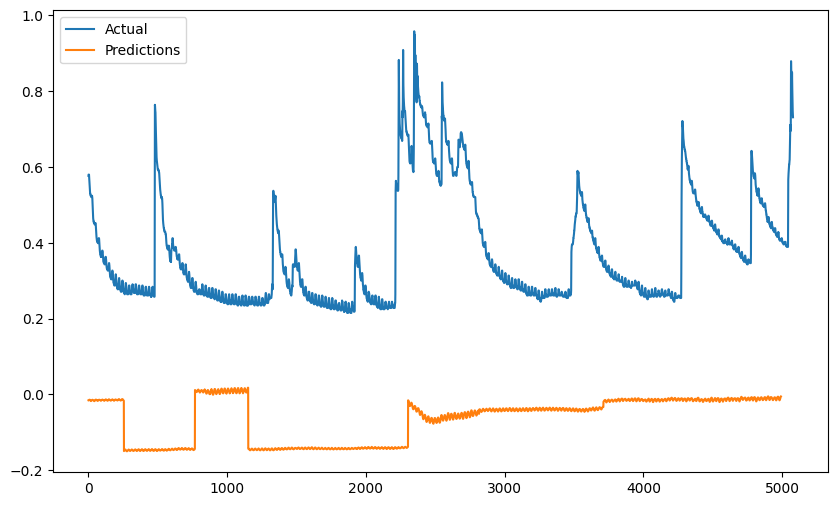

In [77]:
plot_single_pred(lstm_model,'LSTM with Attention', test_dataset, test_steps, y_test, batch_size=BATCH_SIZE)